In [1]:
#!/usr/bin/env python3
# LightGBM classification for 'fail_level'

import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib   # For model persistence

# 1) Load data -----------------------------------------------------------
# If your CSV is named differently, change the path below.
df = pd.read_csv('실패_분류하기_위한.csv')

# 2) Split features and target ------------------------------------------
y = df['fail_level']
X = df.drop(columns=['fail_level'])

# 3) Train / test split --------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 4) Build LightGBM model -----------------------------------------------
# If you have a CUDA-enabled GPU with the LightGBM GPU build,
# change device_type='gpu'.
model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,        # -1 means no limit
    num_leaves=31,
    objective='multiclass',  # 자동으로 클래스 수 감지
    random_state=42,
    device_type='gpu'
)

# 5) Train ---------------------------------------------------------------
model.fit(X_train, y_train)

# 6) Evaluate ------------------------------------------------------------
y_pred = model.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nConfusion matrix\n', confusion_matrix(y_test, y_pred))
print('\nDetailed report\n', classification_report(y_test, y_pred))

# 7) Save model ----------------------------------------------------------
# 결과 모델과 라벨 맵핑을 저장해 두면 재사용 가능
joblib.dump(model, 'lgbm_fail_level.pkl')
print('\nModel saved to lgbm_fail_level.pkl')


[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 1107
[LightGBM] [Info] Number of data points in the train set: 14534, number of used features: 26
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3070, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 26 dense feature groups (0.39 MB) transferred to GPU in 0.054982 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score -3.612984
[LightGBM] [Info] Start training from score -7.281661
[LightGBM] [Info] Start training from score -7.281661
[LightGBM] [Info] Start training from score -0.782325
[LightGBM] [Info] Start training from score -3.457377
[LightGBM] [Info] Start training from score -5.073387
[LightGBM] [Info] Start training from score -6.811657
[LightGBM] [Info] Start training from score -8.891099
[LightGBM] [Info] Start training from sco

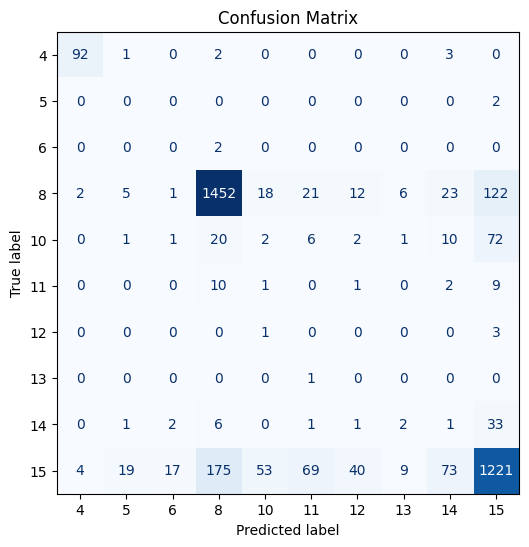

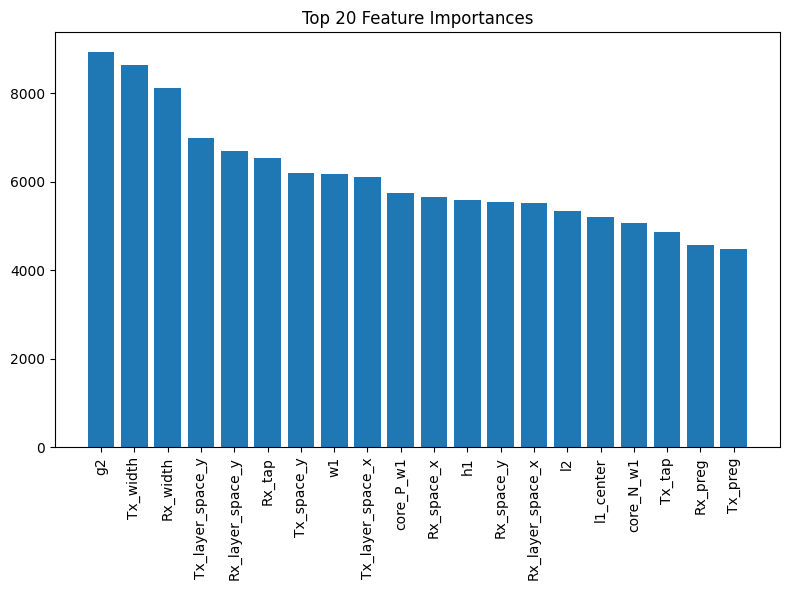

In [2]:
# --------------------------------------------------------
# 8) 시각화: Confusion Matrix, Feature Importance
# --------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
import joblib
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# (1) 모델·데이터 준비 -----------------------------------
# 이미 메모리에 있으면 이 부분 생략
model   = joblib.load('lgbm_fail_level.pkl')
X_test  # train/test split 셀에서 정의돼 있음
y_test

# (2) Confusion Matrix -----------------------------------
y_pred = model.predict(X_test)
cm     = confusion_matrix(y_test, y_pred, labels=model.classes_)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=model.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix')
plt.show()

# (3) Feature Importance ---------------------------------
importances = model.feature_importances_
indices     = np.argsort(importances)[::-1]

top_n = 20                       # 상위 n개만 보기
plt.figure(figsize=(8, 6))
plt.bar(range(top_n), importances[indices][:top_n], align='center')
plt.xticks(range(top_n), X_test.columns[indices][:top_n], rotation=90)
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.show()
